# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

Цель лабораторной работы: изучение способов предварительной обработки данных для дальнейшего формирования моделей.

**Задание:**

Выбрать набор данных (датасет), содержащий категориальные признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.)
Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:

    обработку пропусков в данных;
    кодирование категориальных признаков;
    масштабирование данных.



## Часть 1. Импорт необходимых библиотек и загрузка данных

Для работы нам потребуются библиотеки `pandas` для обработки табличных данных, `numpy` для числовых операций, `matplotlib` и `seaborn` для визуализации, а также модули из `scikit-learn` для предобработки данных.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт инструментов машинного обучения из scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler


%matplotlib inline 
sns.set(style="ticks")

print("Все библиотеки успешно импортированы.")

Все библиотеки успешно импортированы.


### 1.1. Загрузка и первичный осмотр датасета

Загрузим CSV-файл в DataFrame `df` и посмотрим на его структуру: общее количество строк и столбцов, а также первые 5 записей для понимания формата данных.

In [30]:
file_path = 'tested.csv'
df = pd.read_csv(file_path)

print("Размер датасета (строки, колонки):", df.shape)
print("\nПервые 5 строк датасета:")
df.head()

Размер датасета (строки, колонки): (418, 12)

Первые 5 строк датасета:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### 1.2. Анализ типов данных и наличия пропусков

Выведем общую информацию о датасете с помощью метода `.info()`. Это позволит увидеть названия всех колонок, количество непустых (non-null) значений в каждой из них и их типы данных. Также посмотрим на основные статистические характеристики числовых признаков с помощью `.describe()`.

In [31]:
print("Информация о типах данных и пропусках")
df.info()

print("\n\nСтатистика по числовым данным")
df.describe()

Информация о типах данных и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


Статистика по числовым данным


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## 2. Обработка пропусков в данных

Рассмотрим стратегии импьютации - заполнения пропущенных значений для числовых и категориальных признаков.


### 2.1. Обработка пропусков в числовом признаке `Age`

Признак **Age** (возраст пассажира) имеет числовой тип `float64`. 

1. Оценим количество и процент пропусков.
2. Построим гистограмму распределения значений, чтобы понять, какую меру центральной тенденции лучше использовать для заполнения (среднее или медиану). Если распределение скошено или есть выбросы, медиана предпочтительнее.

In [32]:
print("\n\nПроцент пропусков по столбцам:")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))



Процент пропусков по столбцам:
Cabin          78.229665
Age            20.574163
Fare            0.239234
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Ticket          0.000000
Embarked        0.000000
dtype: float64


Количество пропусков в Age: 86
Процент пропусков: 20.57%


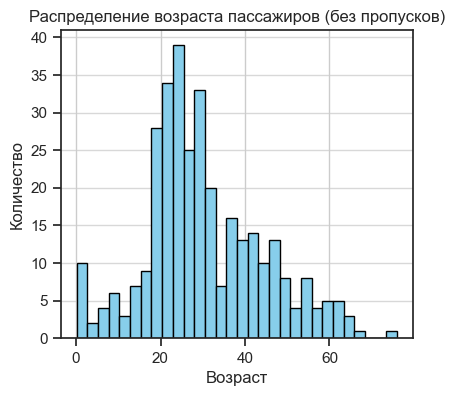

In [33]:
print("Количество пропусков в Age:", df['Age'].isnull().sum())
print("Процент пропусков: {:.2f}%".format(df['Age'].isnull().sum() / len(df) * 100))

# Посмотрим на распределение возраста
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['Age'].dropna().hist(bins=30, edgecolor='black', color='skyblue')
plt.title('Распределение возраста пассажиров (без пропусков)')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [34]:
imputer_median = SimpleImputer(strategy='median')

# Обучаем и трансформируем колонку
df_imputed['Age'] = imputer_median.fit_transform(df_imputed[['Age']])

# Проверяем результат
print("\nПропусков в Age после обработки:", df_imputed['Age'].isnull().sum())
print("Медианное значение, которым были заполнены пропуски:", imputer_median.statistics_[0])


Пропусков в Age после обработки: 0
Медианное значение, которым были заполнены пропуски: 27.0


### 2.2. Заполнение пропусков в `Cabin` константой 'Unknown'

Признак **Cabin** (номер каюты) имеет категориальный тип `object`. Оценим количество пропусков - их очень много (более 77%). Для таких случаев лучше не заполнять пропуски модой, а создать отдельную категорию 'Unknown' (Неизвестно). Используем `SimpleImputer` со стратегией `constant` и параметром `fill_value='Unknown'`.

In [35]:
print("Количество пропусков в Cabin:", df['Cabin'].isnull().sum())
print("Процент пропусков: {:.2f}%".format(df['Cabin'].isnull().sum() / len(df) * 100))

# Для Cabin создадим новую категорию 'Unknown' (так как пропусков очень много)
imputer_constant = SimpleImputer(strategy='constant', fill_value='Unknown')
df_imputed['Cabin'] = imputer_constant.fit_transform(df_imputed[['Cabin']]).ravel()

print("\nУникальные значения в Cabin после обработки (первые 10):")
print(df_imputed['Cabin'].unique()[:10])
print("Количество пропусков:", df_imputed['Cabin'].isnull().sum())

Количество пропусков в Cabin: 327
Процент пропусков: 78.23%

Уникальные значения в Cabin после обработки (первые 10):
['Unknown' 'B45' 'E31' 'B57 B59 B63 B66' 'B36' 'A21' 'C78' 'D34' 'D19'
 'A9']
Количество пропусков: 0


### 2.3. Обработка пропусков в числовом признаке `Fare`

Признак **Fare** (стоимость билета) имеет числовой тип `float64`. Оценим количество пропусков - их всего 1. Для 
заполнения одного пропуска можно использовать медиану или среднее значение. Используем медиану, так как она устойчива 
к выбросам.

In [36]:
print("Количество пропусков в Fare:", df['Fare'].isnull().sum())

# Заполняем пропуск в Fare медианой
imputer_fare = SimpleImputer(strategy='median')
df_imputed['Fare'] = imputer_fare.fit_transform(df_imputed[['Fare']])

print("Пропусков в Fare после обработки:", df_imputed['Fare'].isnull().sum())
print("Медианное значение Fare:", imputer_fare.statistics_[0])

print("Оставшиеся пропуски:\n", df_imputed.isnull().sum())

Количество пропусков в Fare: 1
Пропусков в Fare после обработки: 0
Медианное значение Fare: 14.4542
Оставшиеся пропуски:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## 3. Кодирование категориальных признаков

Текстовые категории необходимо преобразовать в числовой формат, так как большинство алгоритмов машинного обучения работают только с числами.

1. **Label Encoding** — каждое уникальное значение кодируется целым числом (на примере пола `Sex`).
2. **One-Hot Encoding** — каждое уникальное значение становится отдельной бинарной колонкой (на примере порта посадки `Embarked`).
3. **Ручное кодирование порядковых шкал** — задание порядка категорий вручную (на примере класса билета `Pclass`).
4. **Извлечение признаков** — создание новых признаков из существующих (на примере `Cabin`).

### 3.1. Label Encoding для признака `Sex`

Применим `LabelEncoder` к колонке `Sex`. Каждому полу будет присвоен уникальный номер: male -> 0, female -> 1 (или наоборот, в зависимости от алфавитного порядка).

In [37]:
df_encoded = df_imputed.copy()
le_sex = LabelEncoder()
df_encoded['Sex_Encoded'] = le_sex.fit_transform(df_encoded['Sex'])

print("Пример Label Encoding для пола (первые 10 строк):")
print(df_encoded[['Sex', 'Sex_Encoded']].head(10))
print("\nСоответствие кодов:")
for i, sex in enumerate(le_sex.classes_):
    print(f"Код {i} -> {sex}")

Пример Label Encoding для пола (первые 10 строк):
      Sex  Sex_Encoded
0    male            1
1  female            0
2    male            1
3    male            1
4  female            0
5    male            1
6  female            0
7    male            1
8  female            0
9    male            1

Соответствие кодов:
Код 0 -> female
Код 1 -> male


### 3.2. One-Hot Encoding для признака `Embarked`

Используем функцию `pd.get_dummies()` для One-Hot кодирования портов посадки. Для каждого уникального порта (C = Cherbourg, Q = Queenstown, S = Southampton) будет создана отдельная колонка со значениями 0 или 1.

In [38]:
# Создаем датафрейм с One-Hot Encoding для портов
embarked_dummies = pd.get_dummies(df_encoded['Embarked'], prefix='Embarked')

# Присоединяем к основному датафрейму
df_encoded = pd.concat([df_encoded, embarked_dummies], axis=1)

print("Создано колонок для портов посадки:", len(embarked_dummies.columns))
print("\nПример One-Hot кодирования (первые 5 строк):")
print(df_encoded[['Embarked'] + list(embarked_dummies.columns[:3])].head())

Создано колонок для портов посадки: 3

Пример One-Hot кодирования (первые 5 строк):
  Embarked  Embarked_C  Embarked_Q  Embarked_S
0        Q       False        True       False
1        S       False       False        True
2        Q       False        True       False
3        S       False       False        True
4        S       False       False        True


### 3.3. Кодирование порядковой шкалы для признака `Pclass`

Признак **Pclass** (класс билета) уже имеет порядковую структуру: 1 (первый класс) > 2 > 3. Это означает, что чем меньше число, тем выше класс обслуживания. Такая кодировка уже пригодна для использования в моделях, так как сохраняет порядок категорий.

In [39]:
print("Уникальные значения Pclass:", sorted(df_encoded['Pclass'].unique()))
print("Pclass уже является порядковым признаком (1 - высший класс, 3 - низший)")

Уникальные значения Pclass: [np.int64(1), np.int64(2), np.int64(3)]
Pclass уже является порядковым признаком (1 - высший класс, 3 - низший)


### 3.4. Извлечение признака из `Cabin` (первая буква каюты)

Номер каюты содержит информацию о типе каюты (первая буква). Извлечем первую букву в отдельный признак `Cabin_Letter`, а затем применим Label Encoding.

In [40]:
# Извлечем первую букву каюты (тип каюты)
df_encoded['Cabin_Letter'] = df_encoded['Cabin'].str[0]

print("Уникальные значения Cabin_Letter:")
print(df_encoded['Cabin_Letter'].unique())

# Применим Label Encoding для Cabin_Letter
le_cabin = LabelEncoder()
df_encoded['Cabin_Letter_Encoded'] = le_cabin.fit_transform(df_encoded['Cabin_Letter'])

print("\nСоответствие кодов для Cabin_Letter (первые 5):")
for i, letter in enumerate(list(le_cabin.classes_)[:5]):
    print(f"Код {i} -> {letter}")

Уникальные значения Cabin_Letter:
['U' 'B' 'E' 'A' 'C' 'D' 'F' 'G']

Соответствие кодов для Cabin_Letter (первые 5):
Код 0 -> A
Код 1 -> B
Код 2 -> C
Код 3 -> D
Код 4 -> E


## 4. Масштабирование данных

Признаки в исходном датасете измеряются в разных шкалах: 
- `Age` (возраст) — в годах
- `Fare` (стоимость билета) — в фунтах стерлингов
- `SibSp` (количество siblings/spouses) — целые числа от 0 до 8
- `Parch` (количество parents/children) — целые числа от 0 до 6

Если подать такие признаки в неподготовленном виде на вход алгоритмам, чувствительным к масштабу (например, метод k-ближайших соседей, нейронные сети или SVM), то признаки с большими абсолютными значениями будут подавлять остальные.

Два основных способа масштабирования:
1. **StandardScaler** — приводит данные к нормальному распределению с центром в 0 и стандартным отклонением 1 (Z-оценка).
2. **MinMaxScaler** — сжимает данные в заданный интервал [0, 1].

### 4.1. Подготовка данных для масштабирования

Выберем четыре числовых признака с разными масштабами: `Age`, `Fare`, `SibSp`, `Parch`. Создадим копию датафрейма для безопасной работы и убедимся, что пропусков в этих признаках нет.

In [41]:
features_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']

# Создадим копию данных для масштабирования
df_scaled = df_encoded.copy()

# Проверим наличие пропусков в выбранных признаках
print("Пропуски перед масштабированием:")
print(df_scaled[features_to_scale].isnull().sum())

# Обработаем возможные пропуски (хотя мы уже обработали все, на всякий случай)
for col in features_to_scale:
    if df_scaled[col].isnull().sum() > 0:
        imputer_median_scale = SimpleImputer(strategy='median')
        df_scaled[col] = imputer_median_scale.fit_transform(df_scaled[[col]])

print("\nСтатистика исходных данных для масштабирования:")
df_scaled[features_to_scale].describe().round(2)

Пропуски перед масштабированием:
Age      0
Fare     0
SibSp    0
Parch    0
dtype: int64

Статистика исходных данных для масштабирования:


,Age,Fare,SibSp,Parch
count,418.00,418.00,418.00,418.00
mean,29.60,35.58,0.45,0.39
std,12.70,55.85,0.90,0.98
min,0.17,0.00,0.00,0.00
25%,23.00,7.90,0.00,0.00
50%,27.00,14.45,0.00,0.00
75%,35.75,31.47,1.00,0.00
max,76.00,512.33,8.00,9.00


### 4.2. Применение StandardScaler и MinMaxScaler

Создадим экземпляры `StandardScaler` и `MinMaxScaler`, обучим их на выбранных признаках и применим преобразование. Для наглядности добавим новые колонки с суффиксами `_Std` и `_MinMax` к исходному датафрейму.

In [42]:
# 1. StandardScaler (Z-score) - центрирование и масштабирование к единичной дисперсии
std_scaler = StandardScaler()
scaled_data_std = std_scaler.fit_transform(df_scaled[features_to_scale])
df_scaled_std = pd.DataFrame(scaled_data_std, columns=[f'{col}_Std' for col in features_to_scale])

# 2. MinMaxScaler (от 0 до 1) - масштабирование в заданный диапазон
minmax_scaler = MinMaxScaler()
scaled_data_minmax = minmax_scaler.fit_transform(df_scaled[features_to_scale])
df_scaled_minmax = pd.DataFrame(scaled_data_minmax, columns=[f'{col}_MinMax' for col in features_to_scale])

# Объединяем с исходными данными для наглядности
df_scale_comparison = pd.concat([df_scaled[features_to_scale], df_scaled_std, df_scaled_minmax], axis=1)

print("Сравнение масштабированных данных (первые 5 строк):")
df_scale_comparison.head()

Сравнение масштабированных данных (первые 5 строк):


,Age,Fare,SibSp,Parch,Age_Std,Fare_Std,SibSp_Std,Parch_Std,Age_MinMax,Fare_MinMax,SibSp_MinMax,Parch_MinMax
0,34.5,7.8292,0,0,0.386231,-0.497413,-0.499470,-0.400248,0.452723,0.015282,0.000,0.000000
1,47.0,7.0000,1,0,1.371370,-0.512278,0.616992,-0.400248,0.617566,0.013663,0.125,0.000000
2,62.0,9.6875,0,0,2.553537,-0.464100,-0.499470,-0.400248,0.815377,0.018909,0.000,0.000000
3,27.0,8.6625,0,0,-0.204852,-0.482475,-0.499470,-0.400248,0.353818,0.016908,0.000,0.000000
4,22.0,12.2875,1,1,-0.598908,-0.417492,0.616992,0.619896,0.287881,0.023984,0.125,0.111111


### 4.3. Визуализация результатов масштабирования

Построим гистограммы распределения признаков `Fare` и `Age` до и после масштабирования. Это наглядно покажет, как изменился масштаб данных и форма распределения.

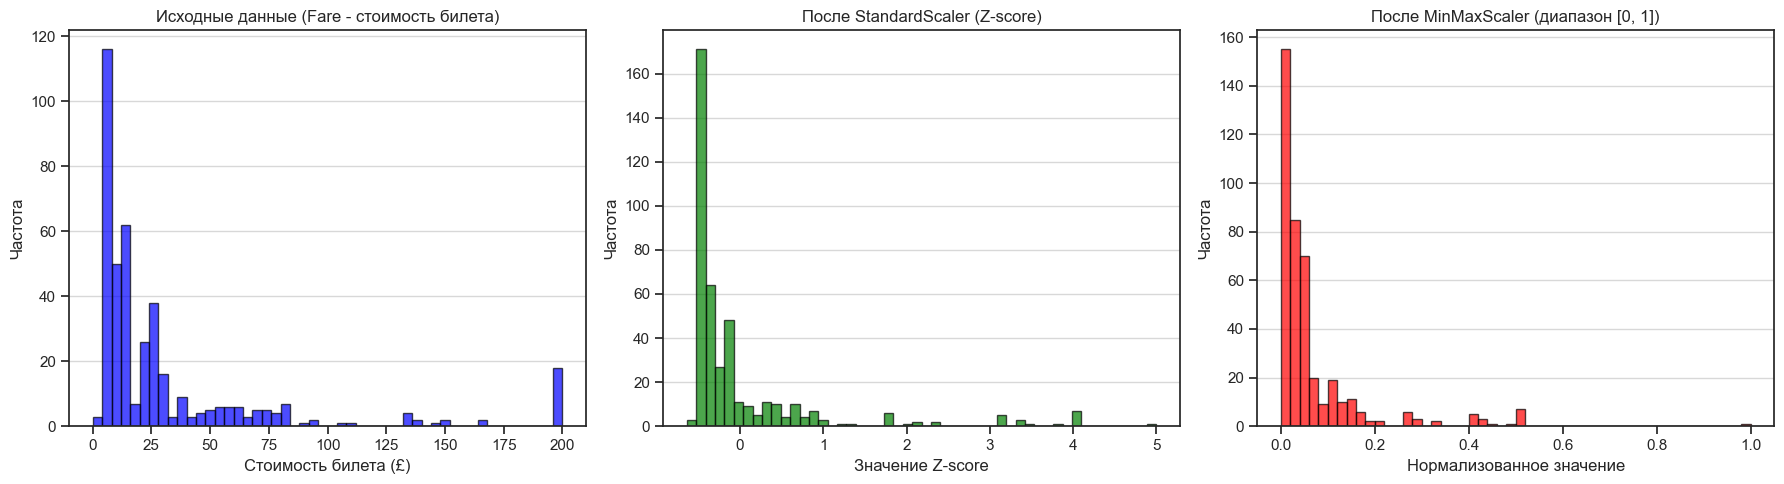

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Исходные данные (Fare - стоимость билета)
axes[0].hist(df_scaled['Fare'].clip(upper=200), bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Исходные данные (Fare - стоимость билета)')
axes[0].set_xlabel('Стоимость билета (£)')
axes[0].set_ylabel('Частота')
axes[0].grid(axis='y', alpha=0.75)

# StandardScaler
axes[1].hist(df_scaled_std['Fare_Std'].clip(lower=-2, upper=5), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('После StandardScaler (Z-score)')
axes[1].set_xlabel('Значение Z-score')
axes[1].set_ylabel('Частота')
axes[1].grid(axis='y', alpha=0.75)

# MinMaxScaler
axes[2].hist(df_scaled_minmax['Fare_MinMax'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[2].set_title('После MinMaxScaler (диапазон [0, 1])')
axes[2].set_xlabel('Нормализованное значение')
axes[2].set_ylabel('Частота')
axes[2].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

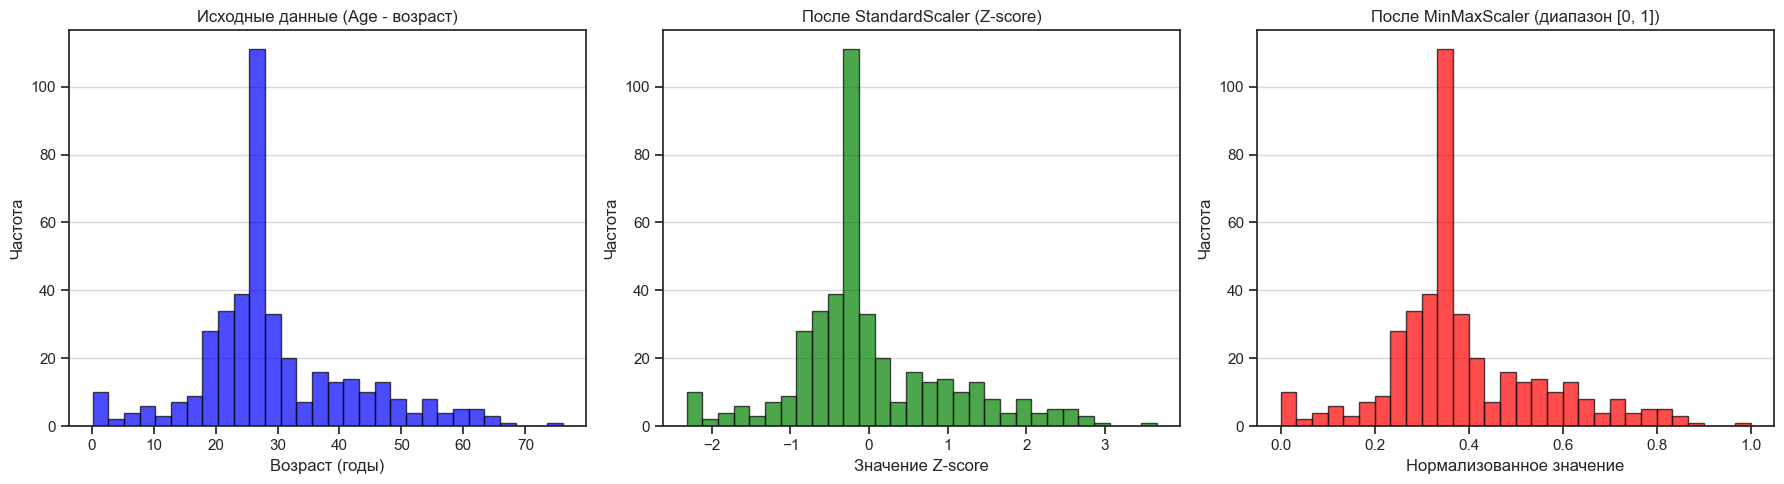

In [44]:
# Визуализация для Age (возраст)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_scaled['Age'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Исходные данные (Age - возраст)')
axes[0].set_xlabel('Возраст (годы)')
axes[0].set_ylabel('Частота')
axes[0].grid(axis='y', alpha=0.75)

axes[1].hist(df_scaled_std['Age_Std'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('После StandardScaler (Z-score)')
axes[1].set_xlabel('Значение Z-score')
axes[1].set_ylabel('Частота')
axes[1].grid(axis='y', alpha=0.75)

axes[2].hist(df_scaled_minmax['Age_MinMax'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[2].set_title('После MinMaxScaler (диапазон [0, 1])')
axes[2].set_xlabel('Нормализованное значение')
axes[2].set_ylabel('Частота')
axes[2].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### 4.4. Сравнительная статистика до и после масштабирования

Выведем описательную статистику для исходных и масштабированных данных. Обратите внимание на среднее (mean) и стандартное отклонение (std) для колонок после `StandardScaler` (близки к 0 и 1 соответственно), а также на минимальное и максимальное значения после `MinMaxScaler` (строго 0 и 1).

In [45]:
print("Сравнительная статистика до и после масштабирования-")
df_scale_comparison.describe().round(2)

Сравнительная статистика до и после масштабирования-


,Age,Fare,SibSp,Parch,Age_Std,Fare_Std,SibSp_Std,Parch_Std,Age_MinMax,Fare_MinMax,SibSp_MinMax,Parch_MinMax
count,418.00,418.00,418.00,418.00,418.00,418.00,418.00,418.00,418.00,418.00,418.00,418.00
mean,29.60,35.58,0.45,0.39,0.00,0.00,-0.00,-0.00,0.39,0.07,0.06,0.04
std,12.70,55.85,0.90,0.98,1.00,1.00,1.00,1.00,0.17,0.11,0.11,0.11
min,0.17,0.00,0.00,0.00,-2.32,-0.64,-0.50,-0.40,0.00,0.00,0.00,0.00
25%,23.00,7.90,0.00,0.00,-0.52,-0.50,-0.50,-0.40,0.30,0.02,0.00,0.00
50%,27.00,14.45,0.00,0.00,-0.20,-0.38,-0.50,-0.40,0.35,0.03,0.00,0.00
75%,35.75,31.47,1.00,0.00,0.48,-0.07,0.62,-0.40,0.47,0.06,0.12,0.00
max,76.00,512.33,8.00,9.00,3.66,8.55,8.43,8.78,1.00,1.00,1.00,1.00


## Заключение

В ходе выполнения лабораторной работы были освоены и применены на практике ключевые методы предварительной обработки данных с использованием библиотеки `scikit-learn`:

1.  **Обработка пропусков:**
    - Для числового признака `Age` (возраст) успешно применена импьютация медианой 
     с помощью `SimpleImputer(strategy='median')`.
    - Для категориального признака `Embarked` (порт посадки) успешно применена 
     импьютация модой (наиболее частым значением).
    - Для категориального признака `Cabin` (каюта) успешно применена импьютация 
     константой `Unknown` с помощью `SimpleImputer(strategy='constant')`.

2.  **Кодирование категориальных признаков:**
    - Продемонстрирован LabelEncoder на примере колонки `Sex` (пол).
    - Выполнено One-Hot кодирование колонки `Embarked` с помощью `pd.get_dummies()`.
    - Извлечен новый признак `Cabin_Letter` из колонки `Cabin` и закодирован.

3.  **Масштабирование данных:**
    - К числовым признакам ('Age', 'Fare', 'SibSp', 'Parch') применены 
     `StandardScaler` (Z-оценка) и `MinMaxScaler` (масштабирование в диапазон [0, 1]).
    - Визуализация и сравнительная статистика подтвердили корректность преобразований.

Все поставленные задачи выполнены. Полученный в результате набор данных готов к дальнейшему использованию для построения моделей машинного обучения.